**NAMA : MOCH. ALIFFIAN**


**NIM : 22.11.5294**

***JUDUL PROJECT***


**Ship Performance Clustering**

Kolom dengan nilai hilang: ['Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
Jumlah nilai hilang setelah preprocessing:
Date                       0
Ship_Type                  0
Route_Type                 0
Engine_Type                0
Maintenance_Status         0
Speed_Over_Ground_knots    0
Engine_Power_kW            0
Distance_Traveled_nm       0
Draft_meters               0
Weather_Condition          0
Cargo_Weight_tons          0
Operational_Cost_USD       0
Revenue_per_Voyage_USD     0
Turnaround_Time_hours      0
Efficiency_nm_per_kWh      0
Seasonal_Impact_Score      0
Weekly_Voyage_Count        0
Average_Load_Percentage    0
dtype: int64


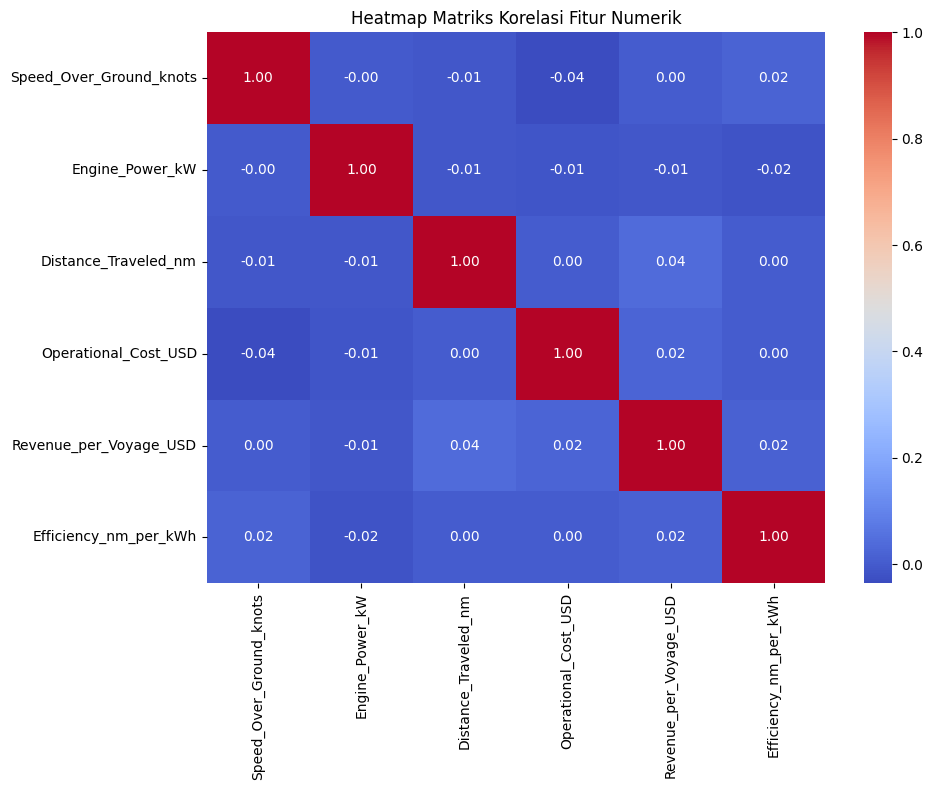

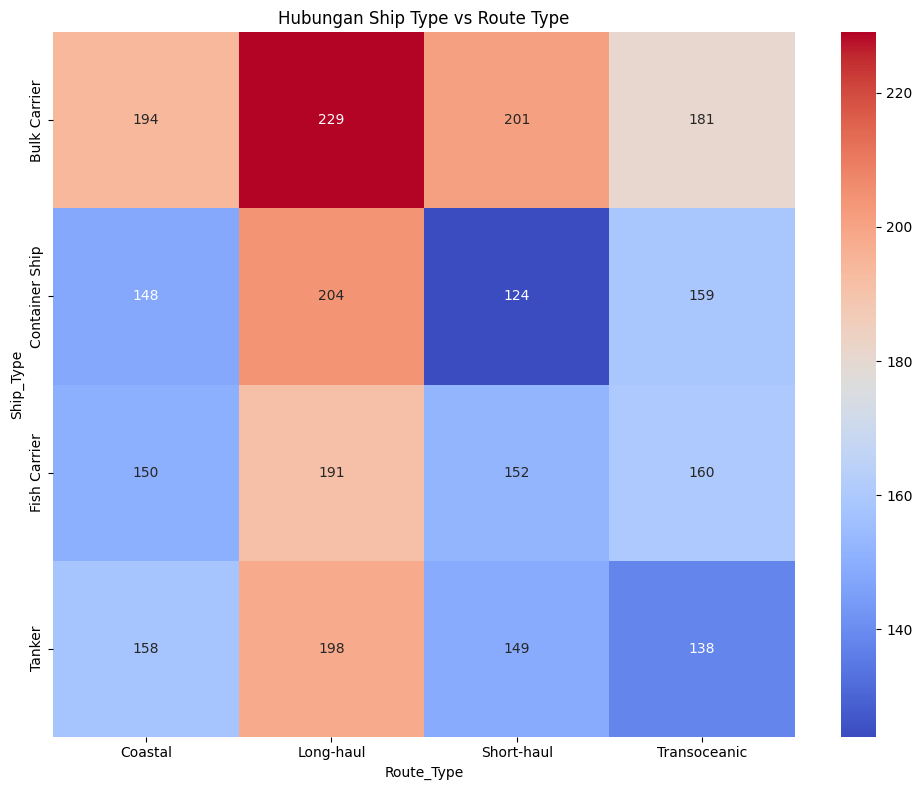

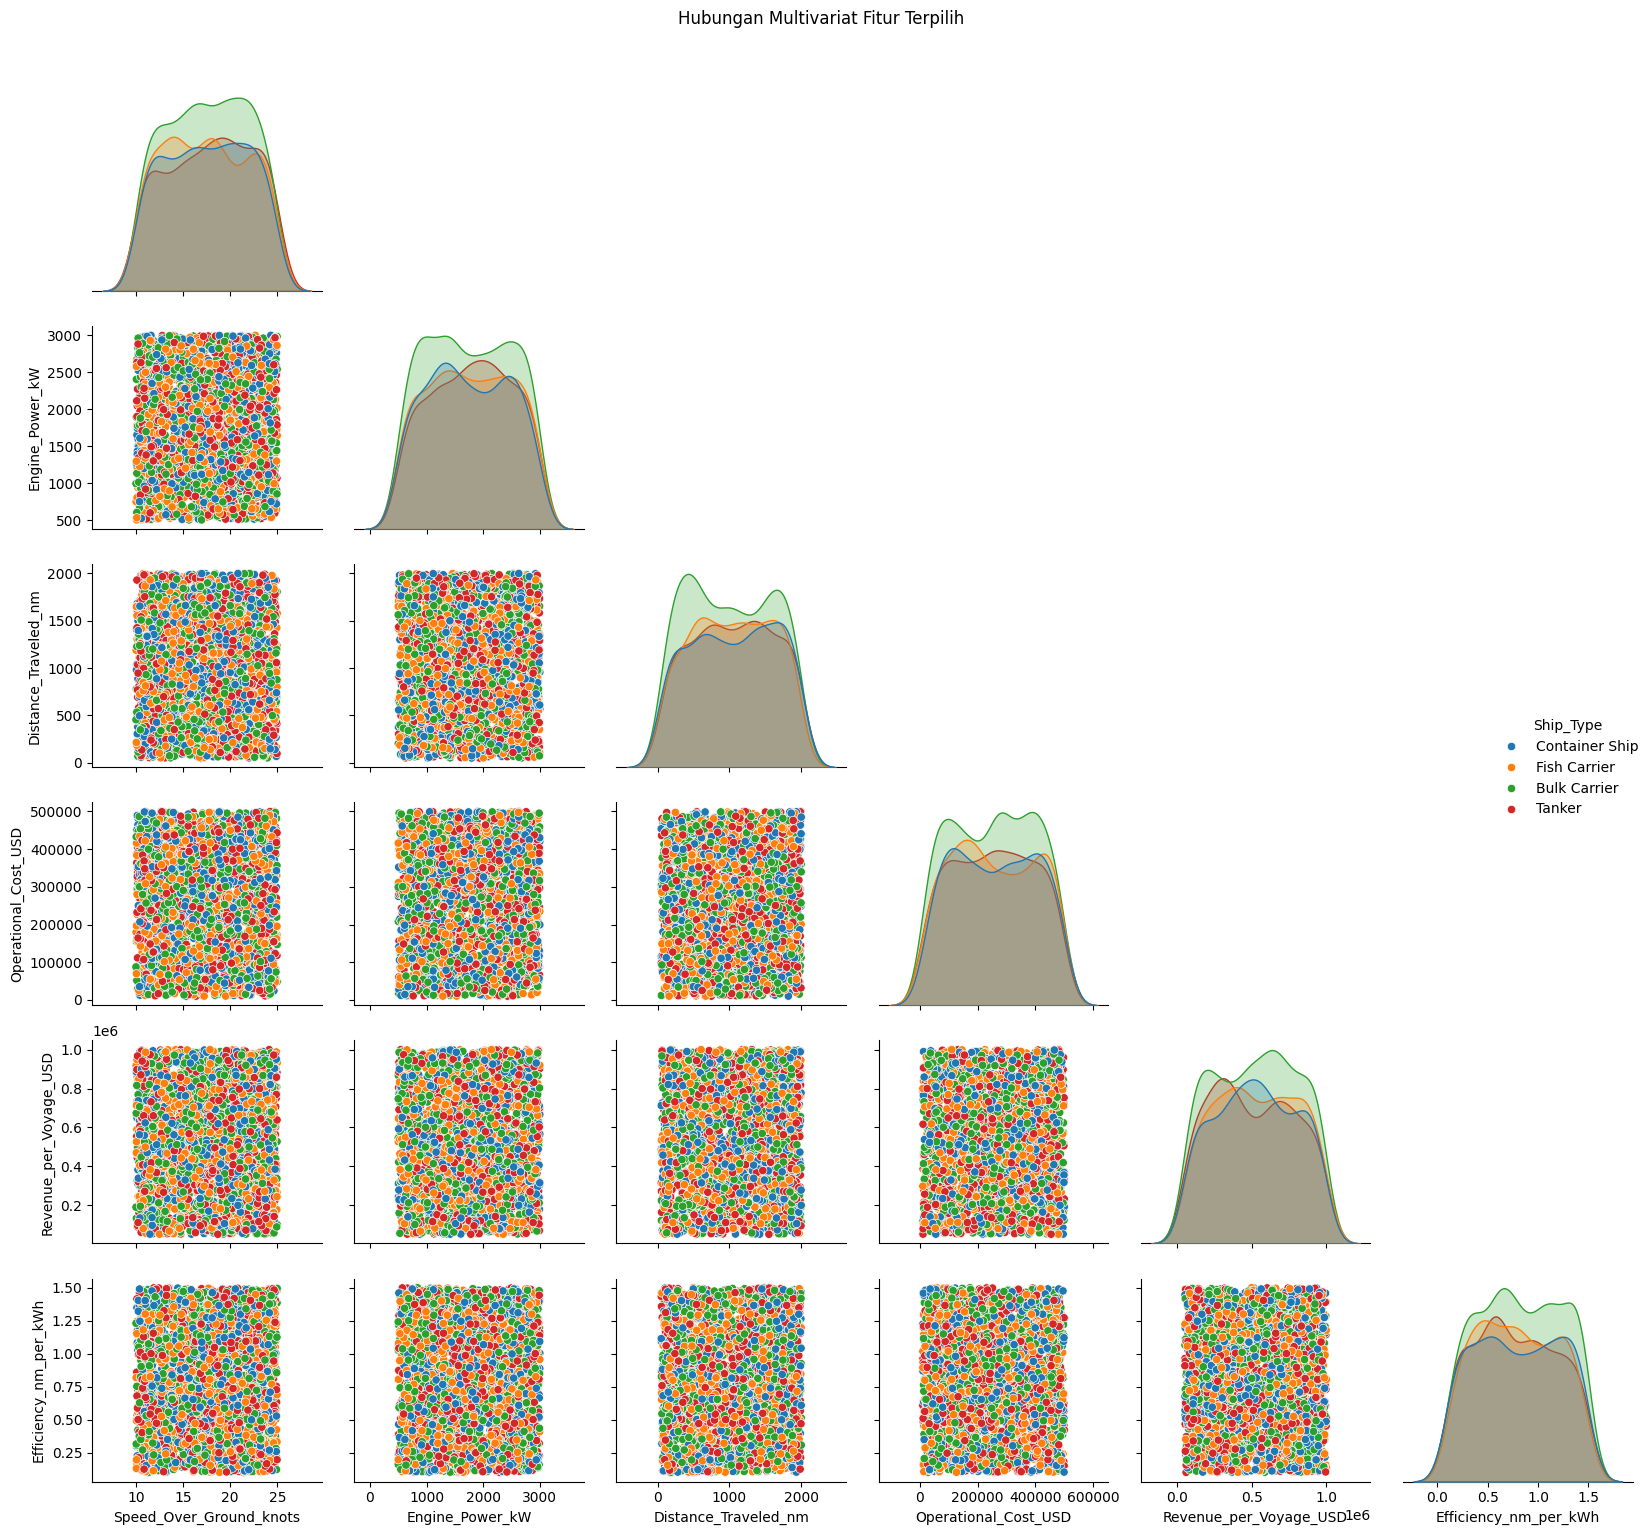

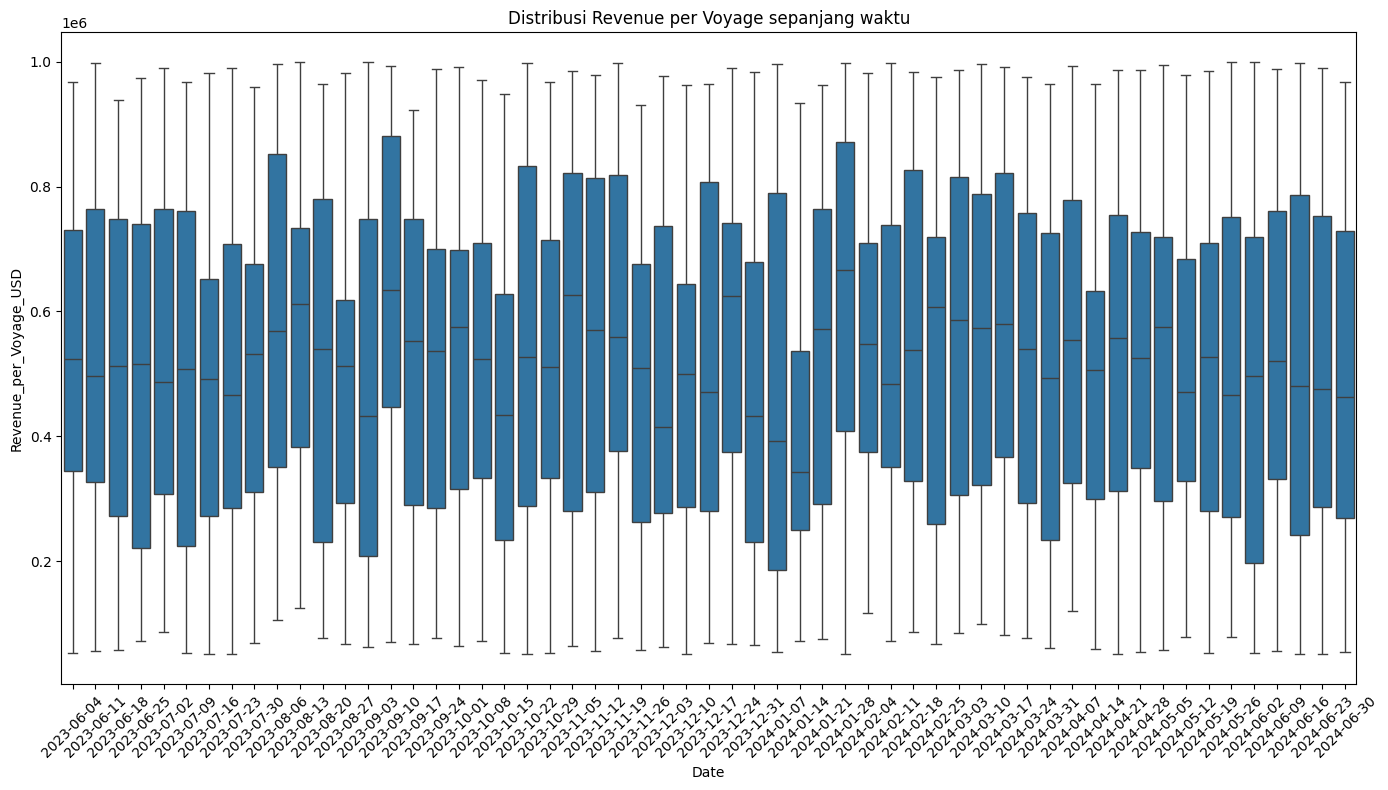

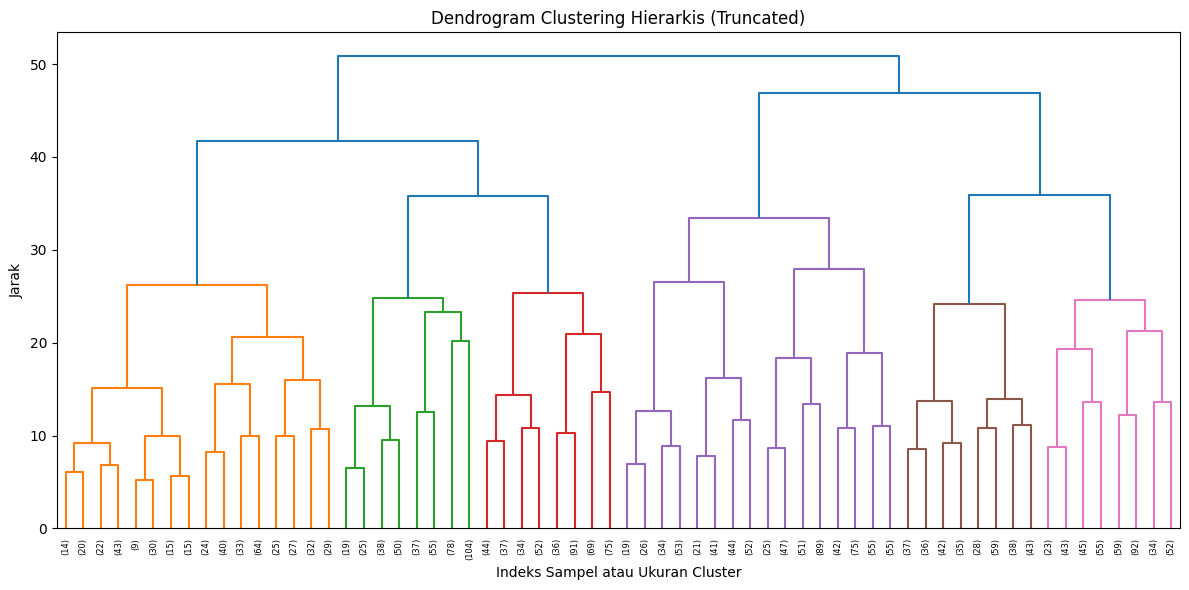

Silhouette Score untuk KMeans: 0.11
Silhouette Score untuk Clustering Hierarkis: 0.07
Calinski-Harabasz Index untuk KMeans: 348.52
Calinski-Harabasz Index untuk Clustering Hierarkis: 233.53
Davies-Bouldin Index untuk KMeans: 2.24
Davies-Bouldin Index untuk Clustering Hierarkis: 2.72


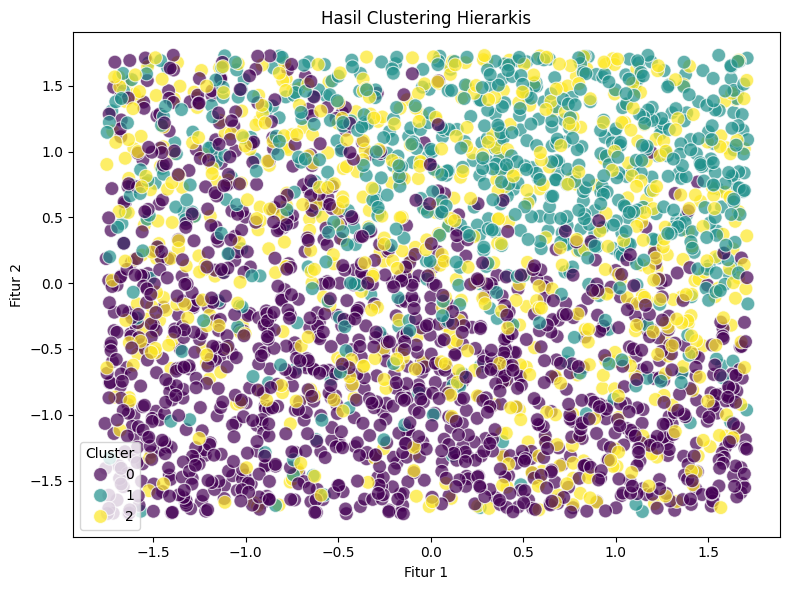

PCA-based Silhouette Score: 0.35


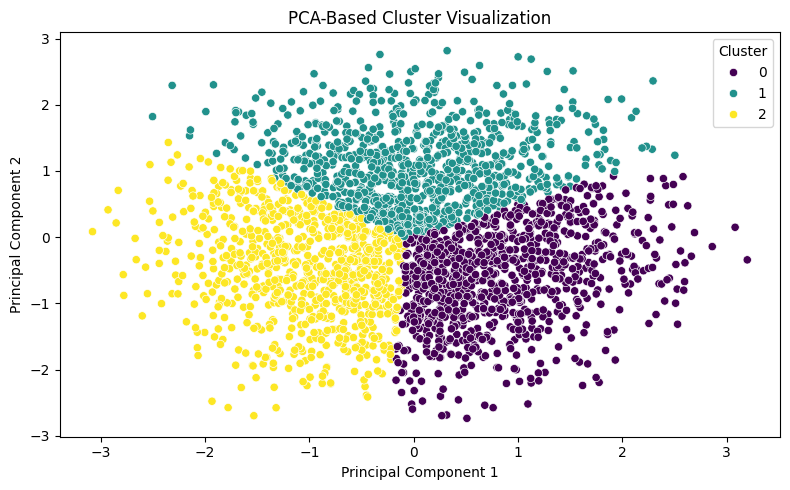

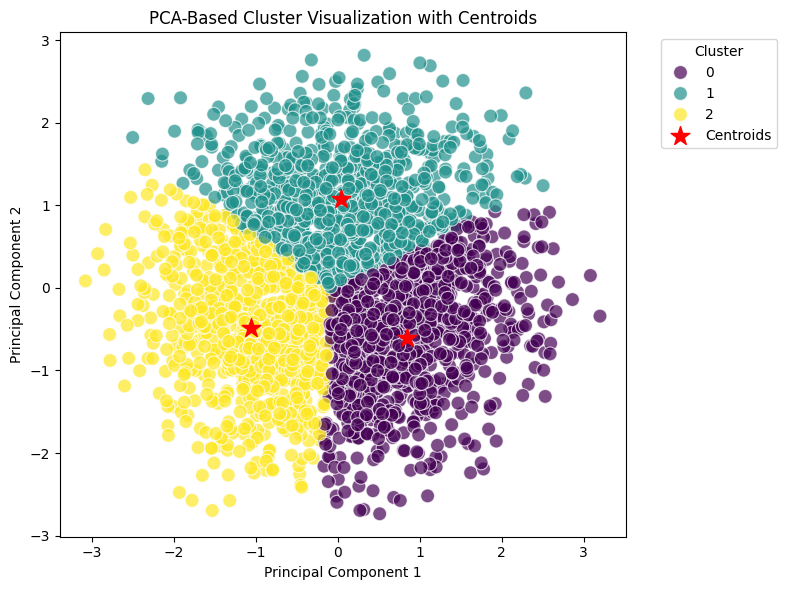


Ringkasan Profil Cluster (KMeans):
         Speed_Over_Ground_knots  Engine_Power_kW  Distance_Traveled_nm  \
Cluster                                                                   
0                      -0.032205         0.010134              0.009013   
1                       0.139891         0.134848             -0.097062   
2                      -0.123977        -0.157901              0.098450   

         Operational_Cost_USD  Revenue_per_Voyage_USD  Efficiency_nm_per_kWh  
Cluster                                                                       
0                    0.774788                0.091582              -0.831078  
1                   -1.016023               -0.164871              -0.206486  
2                    0.396135                0.096116               1.002192  

Ringkasan Evaluasi Clustering:
Silhouette Score (KMeans): 0.11
Silhouette Score (Hierarkis): 0.07
Calinski-Harabasz Index (KMeans): 348.52
Calinski-Harabasz Index (Hierarkis): 233.53
Davies-Bo

In [15]:
# Import pustaka yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Memuat dataset
data = pd.read_csv("/content/Ship_Performance_Dataset.csv")

# Salin dataset untuk menjaga data asli tetap aman
df = data.copy()

# --- Preprocessing Data ---

# 1. Menangani nilai yang hilang (missing values)
missing_columns = df.columns[df.isnull().any()].tolist()
print(f"Kolom dengan nilai hilang: {missing_columns}")

# Mengisi nilai hilang pada kolom kategorikal dengan modus
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col in missing_columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Mengisi nilai hilang pada kolom numerik dengan median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if col in missing_columns:
        df[col] = df[col].fillna(df[col].median())

# Verifikasi nilai hilang telah ditangani
print("Jumlah nilai hilang setelah preprocessing:")
print(df.isnull().sum())

# 2. Konversi kolom 'Date' menjadi tipe data datetime
df['Date'] = pd.to_datetime(df['Date'])

# 3. Fitur numerik yang relevan untuk analisis
selected_features = [
    'Speed_Over_Ground_knots',
    'Engine_Power_kW',
    'Distance_Traveled_nm',
    'Operational_Cost_USD',
    'Revenue_per_Voyage_USD',
    'Efficiency_nm_per_kWh'
]

# 4. Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[selected_features])

# --- Analisis Korelasi ---

# Menghitung matriks korelasi
correlation_matrix = df[selected_features].corr()

# Visualisasi matriks korelasi menggunakan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

# --- Visualisasi ---

# 1. Heatmap hubungan antara variabel kategorikal
categorical_cols = ['Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
plt.figure(figsize=(10, 8))
cat_counts = pd.crosstab(df['Ship_Type'], df['Route_Type'])
sns.heatmap(cat_counts, annot=True, cmap="coolwarm", fmt="d")
plt.title("Hubungan Ship Type vs Route Type")
plt.tight_layout()
plt.show()

# 2. Pairplot untuk fitur numerik yang dipilih
sns.pairplot(df[selected_features + ['Ship_Type']], hue='Ship_Type', diag_kind="kde", corner=True)
plt.suptitle("Hubungan Multivariat Fitur Terpilih", y=1.02)
plt.tight_layout()
plt.show()

# 3. Boxplot distribusi Revenue per Voyage berdasarkan waktu
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Date', y='Revenue_per_Voyage_USD', showfliers=False)
plt.title("Distribusi Revenue per Voyage sepanjang waktu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Clustering Hierarkis ---

# Membuat matriks linkage untuk dendrogram
linkage_matrix = linkage(scaled_data, method='ward')

# Menampilkan dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrogram Clustering Hierarkis (Truncated)')
plt.xlabel('Indeks Sampel atau Ukuran Cluster')
plt.ylabel('Jarak')
plt.tight_layout()
plt.show()

# Agglomerative Clustering dengan 3 cluster
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_clusters = hierarchical.fit_predict(scaled_data)

# Menambahkan hasil cluster ke dataset
df['Hierarchical_Cluster'] = hierarchical_clusters

# --- Clustering KMeans ---

# Menggunakan KMeans untuk clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(scaled_data)

# --- Evaluasi Silhouette Score ---

# Silhouette Score untuk KMeans dan Agglomerative Clustering
kmeans_score = silhouette_score(scaled_data, kmeans_clusters)
hierarchical_score = silhouette_score(scaled_data, hierarchical_clusters)

# --- Evaluasi Tambahan ---

# Calinski-Harabasz Index
kmeans_ch_score = calinski_harabasz_score(scaled_data, kmeans_clusters)
hierarchical_ch_score = calinski_harabasz_score(scaled_data, hierarchical_clusters)

# Davies-Bouldin Index
kmeans_db_score = davies_bouldin_score(scaled_data, kmeans_clusters)
hierarchical_db_score = davies_bouldin_score(scaled_data, hierarchical_clusters)

# Menampilkan hasil evaluasi
print(f"Silhouette Score untuk KMeans: {kmeans_score:.2f}")
print(f"Silhouette Score untuk Clustering Hierarkis: {hierarchical_score:.2f}")
print(f"Calinski-Harabasz Index untuk KMeans: {kmeans_ch_score:.2f}")
print(f"Calinski-Harabasz Index untuk Clustering Hierarkis: {hierarchical_ch_score:.2f}")
print(f"Davies-Bouldin Index untuk KMeans: {kmeans_db_score:.2f}")
print(f"Davies-Bouldin Index untuk Clustering Hierarkis: {hierarchical_db_score:.2f}")

# Visualisasi hasil clustering Agglomerative
plt.figure(figsize=(8, 6))
sns.scatterplot(x=scaled_data[:, 0], y=scaled_data[:, 1], hue=hierarchical_clusters, palette='viridis', s=100, alpha=0.7)
plt.title('Hasil Clustering Hierarkis')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

# --- PCA dan Clustering ---

# Menggunakan PCA untuk reduksi dimensi
optimal_k = 3  # Jumlah cluster
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# K-Means pada data yang telah diubah dengan PCA
pca_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
pca_clusters = pca_kmeans.fit_predict(pca_data)

# Menghitung Silhouette Score untuk clustering berbasis PCA
pca_silhouette_avg = silhouette_score(pca_data, pca_clusters)
print(f"PCA-based Silhouette Score: {pca_silhouette_avg:.2f}")

# Visualisasi clustering berbasis PCA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=pca_clusters, palette='viridis')
plt.title('PCA-Based Cluster Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Visualisasi clustering berbasis PCA dengan centroids
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=pca_clusters, palette='viridis', s=100, alpha=0.7)
plt.scatter(pca_kmeans.cluster_centers_[:, 0], pca_kmeans.cluster_centers_[:, 1], c='red', s=200, marker='*', label='Centroids')
plt.title('PCA-Based Cluster Visualization with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Enhanced_PCA_Cluster_Visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Ringkasan Hasil ---

# Profil cluster berdasarkan hasil KMeans
cluster_summary = pd.DataFrame(scaled_data, columns=selected_features)
cluster_summary['Cluster'] = kmeans_clusters
cluster_profiles = cluster_summary.groupby('Cluster').mean()

print("\nRingkasan Profil Cluster (KMeans):")
print(cluster_profiles)

# Ringkasan hasil evaluasi
print("\nRingkasan Evaluasi Clustering:")
print(f"Silhouette Score (KMeans): {kmeans_score:.2f}")
print(f"Silhouette Score (Hierarkis): {hierarchical_score:.2f}")
print(f"Calinski-Harabasz Index (KMeans): {kmeans_ch_score:.2f}")
print(f"Calinski-Harabasz Index (Hierarkis): {hierarchical_ch_score:.2f}")
print(f"Davies-Bouldin Index (KMeans): {kmeans_db_score:.2f}")
print(f"Davies-Bouldin Index (Hierarkis): {hierarchical_db_score:.2f}")
print(f"PCA-based Silhouette Score: {pca_silhouette_avg:.2f}")
